# AI: Machine Learning Foundations, Assignment 1: Data Preparation
**Name:** ADAM KHOURY  
**GitHub Repository:** https://github.com/adamkhouryedy2308-eng/ML-fundamentals-2026.git




---
## 0. Setup and Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('All imports successful.')

All imports successful.


---
## Task 1: Identifying the Prediction Target
*Lecture 1 (Supervised Learning, Problem Formulation)*


### The target: `y`

`y` tells us whether a client subscribed to a term deposit (`yes` / `no`). That's exactly what the campaign is trying to figure out in advance. Given what we know about a client before the call, will they subscribe? So `y` is the target.

### Why `duration` is NOT a valid feature

`duration` is the call length in seconds. It's tempting to use because longer calls strongly predict subscription, but you only know the call length *after* the call ends. By then, the decision has already been made. Using it would be a textbook case of target leakage as we mentioned in (Lecture 4).The dataset documentation also explicitly says not to use it. I drop it immediately after loading, before anything else runs.

### Why `poutcome` is not a target

`poutcome` records what happened in a previous campaign. The name sounds like an outcome, and it is, but it's a past outcome the bank already has on file before making the call. It's a feature, not what we're predicting.

### Why `pdays` could be confused

`pdays` uses 999 as a code for "never contacted before" which makes it look a bit like a derived outcome variable. But it's just a CRM field the bank knows ahead of time, it's a feature with a weird encoding, not a target. I will deal with that encoding in Task 4.

---
## Task 2: Data Loading and Exploration
*Lecture 1 (Problem Formulation), Lecture 3 (Data Collection and Preparation)*

I want each plot and statistic here to actually say something useful, not just exist to tick boxes. The goal is to understand the dataset well enough to make good decisions in the preprocessing steps later.

### 2.1 — Load the dataset

In [ ]:
df = pd.read_csv('bank-additional.csv', sep=';')
print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Dataset shape: 4,119 rows x 21 columns


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


### 2.2  Structure: observations, features, data types

In [ ]:
print('=== Data Types ===')
df.info()

=== Data Types ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx 

In [ ]:
# Identify numerical vs categorical variables
numerical_cols   = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f'Numerical columns  ({len(numerical_cols)}): {numerical_cols}')
print()
print(f'Categorical columns ({len(categorical_cols)}): {categorical_cols}')

Numerical columns  (10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical columns (11): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


The dataset has 4,119 rows and 21 columns — 20 features plus the target. Ten are numeric and eleven are categorical (including `y`). No mixed types, which simplifies things.

### 2.3 Summary statistics for numerical variables

In [ ]:
df.describe().T[['mean','std','min','25%','50%','75%','max']].round(2)

,mean,std,min,25%,50%,75%,max
age,40.11,10.31,18.00,32.00,38.00,47.00,88.00
duration,256.79,254.70,0.00,103.00,181.00,317.00,3643.00
campaign,2.54,2.57,1.00,1.00,2.00,3.00,35.00
pdays,960.42,191.92,0.00,999.00,999.00,999.00,999.00
previous,0.19,0.54,0.00,0.00,0.00,0.00,6.00
emp.var.rate,0.08,1.56,-3.40,-1.80,1.10,1.40,1.40
cons.price.idx,93.58,0.58,92.20,93.08,93.75,93.99,94.77
cons.conf.idx,-40.50,4.59,-50.80,-42.70,-41.80,-36.40,-26.90
euribor3m,3.62,1.73,0.64,1.33,4.86,4.96,5.04
nr.employed,5166.48,73.67,4963.60,5099.10,5191.00,5228.10,5228.10


One thing that immediately stands out is the scale difference across numerical features. `nr.employed` is around 5,000, while `previous` is typically 0–2 and rarely hits 6. `campaign` has a max of 56 but most values are under 10. This kind of mismatch causes real problems for logistic regression, the gradient steps end up dominated by whichever feature has the biggest values. Standardisation is definitely needed here.

### 2.4 Target variable distribution and class imbalance

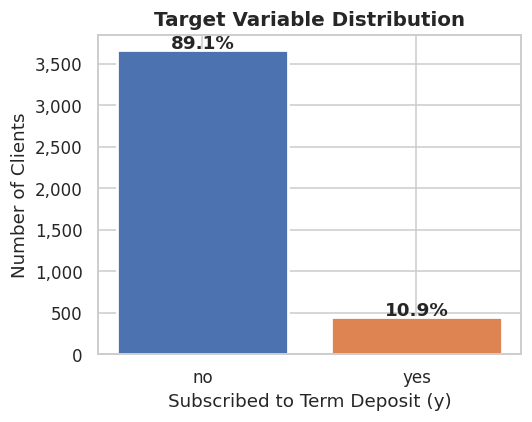

Class breakdown:
  no: 3,668 (89.1%)
  yes: 451 (10.9%)
Imbalance ratio: 8.1:1


In [ ]:
counts = df['y'].value_counts()
pcts   = df['y'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(5, 4))
colors = ['#4C72B0', '#DD8452']
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.8)
for bar, (label, pct) in zip(bars, pcts.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 12,
            f'{pct:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Target Variable Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Subscribed to Term Deposit (y)')
ax.set_ylabel('Number of Clients')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print(f'Class breakdown:')
for label in counts.index:
    print(f'  {label}: {counts[label]:,} ({pcts[label]:.1f}%)')
print(f'Imbalance ratio: {counts["no"]/counts["yes"]:.1f}:1')

The class split is 89% `no` vs 11% `yes` which is about an 8:1 ratio. That's a big imbalance. A model that just predicts `no` for every client would get 89% accuracy without learning anything useful, this is what Lecture 10 calls the **Zero Rule baseline**, and it's the minimum bar any real model has to beat. This means accuracy alone isn't a good metric for this task, and I'll need to handle the imbalance before training (Task 8). It also means I need to stratify the split. Otherwise I might end up with very few `yes` examples in the validation set just by chance.

### 2.5 Explicit and implicit missing values

In [ ]:
print(f'Explicit NaN values: {df.isnull().sum().sum()}')
print()
print('Implicit missing values (string "unknown"):')
has_unknown = False
for col in df.select_dtypes(include='object').columns:
    n = (df[col] == 'unknown').sum()
    if n > 0:
        has_unknown = True
        print(f'  {col:20s}: {n:>4} ({n/len(df)*100:.1f}%)')
if not has_unknown:
    print('  None found.')
print()
sentinel = (df['pdays'] == 999).sum()
print(f'Numerical sentinel value pdays=999 (never contacted): {sentinel} ({sentinel/len(df)*100:.1f}%)')

Explicit NaN values: 0

Implicit missing values (string "unknown"):
  job                 :   39 (0.9%)
  marital             :   11 (0.3%)
  education           :  167 (4.1%)
  default             :  803 (19.5%)
  housing             :  105 (2.5%)
  loan                :  105 (2.5%)

Numerical sentinel value pdays=999 (never contacted): 3959 (96.1%)


No NaN values at all, which is nice. But there are `'unknown'` strings in six columns, these are the implicit missing values that we talked about in class. `default` is the worst at 19.5% unknown. The `pdays` column also has 999 as a special code for "never contacted", which isn't really a number, it's more like a category. I'll treat both of these carefully in Task 4.

### 2.6 Distribution of two numerical variables

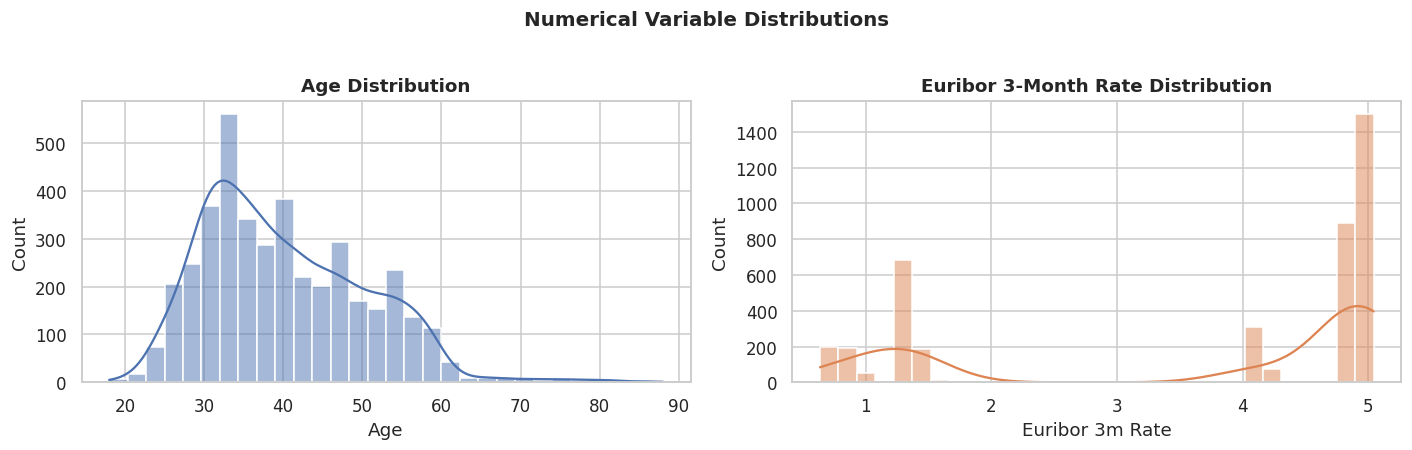

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Plot 1: age distribution
sns.histplot(df['age'], bins=30, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Age Distribution', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Plot 2: euribor3m distribution — bimodal, economically significant
sns.histplot(df['euribor3m'], bins=30, kde=True, ax=axes[1], color='#DD8452')
axes[1].set_title('Euribor 3-Month Rate Distribution', fontweight='bold')
axes[1].set_xlabel('Euribor 3m Rate')
axes[1].set_ylabel('Count')

plt.suptitle('Numerical Variable Distributions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

`age` looks fairly normal with a slight right skew. Nothing unusual there.

`euribor3m` is interesting, it has a clear bimodal shape with one cluster near 1.3 and another near 4.9. This probably reflects different economic periods in the data. It's also going to be highly correlated with the other macroeconomic features, which I'll need to handle in feature selection.

### 2.7 Distribution of two categorical variables

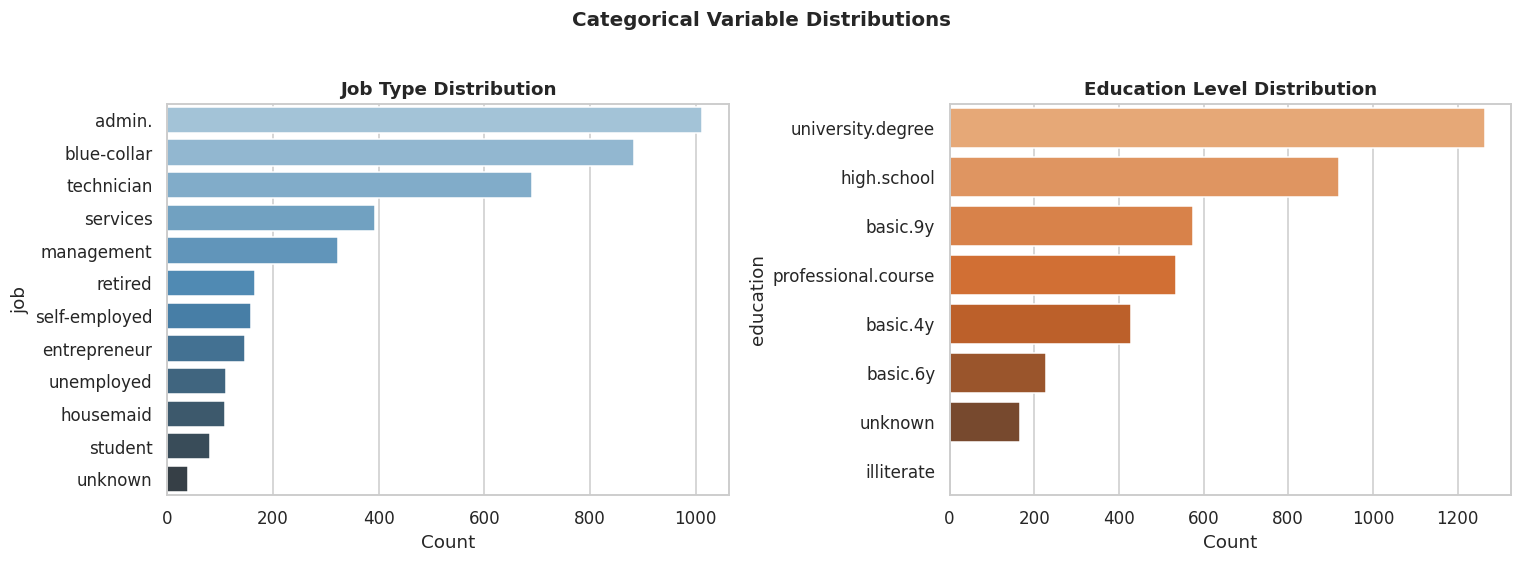

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: job
job_counts = df['job'].value_counts()
sns.barplot(y=job_counts.index, x=job_counts.values, ax=axes[0],
            hue=job_counts.index, palette='Blues_d', orient='h', legend=False)
axes[0].set_title('Job Type Distribution', fontweight='bold')
axes[0].set_xlabel('Count')

# Plot 2: education — shows the natural ordering
edu_counts = df['education'].value_counts()
sns.barplot(y=edu_counts.index, x=edu_counts.values, ax=axes[1],
            hue=edu_counts.index, palette='Oranges_d', orient='h', legend=False)
axes[1].set_title('Education Level Distribution', fontweight='bold')
axes[1].set_xlabel('Count')

plt.suptitle('Categorical Variable Distributions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

`job` is quite unbalanced as `admin.` and `blue-collar` dominate and some categories like `unknown` or `housemaid` are very rare. That matters because rare OHE columns end up with near-zero variance and will probably get removed in feature selection anyway.

`education` is interesting because you can clearly see a natural ordering in the categories; from basic schooling up to university degree. That tells me ordinal encoding is going to be a better fit here than one hot encoding.

### 2.8 Special variable requiring consideration: `pdays`

In [ ]:
print('pdays value distribution (top values):')
print(df['pdays'].value_counts().head(10))
print()
print(f'Records with pdays = 999 (sentinel): {(df["pdays"]==999).sum()} ({(df["pdays"]==999).mean()*100:.1f}%)')
print(f'Records with real numeric pdays:      {(df["pdays"]!=999).sum()} ({(df["pdays"]!=999).mean()*100:.1f}%)')
print()
print('Skewness of all numerical columns:')
print(df[numerical_cols].skew().sort_values(ascending=False).round(2))

pdays value distribution (top values):
pdays
999    3959
3        52
6        42
4        14
7        10
10        8
12        5
5         4
2         4
1         3
Name: count, dtype: int64

Records with pdays = 999 (sentinel): 3959 (96.1%)
Records with real numeric pdays:      160 (3.9%)

Skewness of all numerical columns:
previous          4.02
campaign          4.00
duration          3.29
age               0.72
cons.conf.idx     0.29
cons.price.idx   -0.22
euribor3m        -0.72
emp.var.rate     -0.73
nr.employed      -1.08
pdays            -4.78
dtype: float64


`pdays` is basically useless as a raw number. 96% of values are 999, which means "was never previously contacted." If I kept it as is, the model would just learn a big negative coefficient for 999 and nothing meaningful about actual contact timing. The right move is to extract the useful part (was this person ever contacted before, yes or no) and drop the rest.

---
## Task Ordering
*Lecture 4 (Data Leakage, Data Partitioning), Lecture 7 (Feature Scaling), Lecture 9 (ML Pipeline)*

The tasks in the brief are listed alphabetically, but I need to figure out the right order myself. The core rule is simple: anything that learns from the data, imputers, scalers, encoders, feature selectors, SMOTE has to be fitted on training data only. Which means the split has to happen first.

### My chosen order and why

| Step | Task | What I can use | What I can't use | Leakage if wrong |
|------|------|----------------|------------------|------------------|
| 1 | Identify prediction target | Domain knowledge | Nothing yet | N/A |
| 2 | Load and explore | Full dataset, read-only | Can't fit anything | N/A |
| 3 | Task ordering | Logic | Nothing | N/A |
| **4** | **Split the data** | **Full dataset** | **Any fitted parameters** | **Everything below this leaks** |
| 5 | Handle missing values | Training set only for fitting | Val/test stats | Imputer absorbs test distribution |
| 6 | Encode categoricals | Training vocabulary only | Val/test categories | Encoder sees future data |
| 7 | Scale features | Training mean/std only | Val/test scale | Scaler shifts using test values |
| 8 | Feature selection | Training variance/corr only | Val/test structure | Features picked based on test set |
| 9 | Address class imbalance | Training labels only | Val/test samples | Synthetic points contaminate eval |
| 10 | Train model | Resampled training set | Test set | Evaluation isn't blind |

### A few things worth explaining

**Why split before everything else:** If I scale before splitting, the scaler sees the whole dataset including test rows and computes means and standard deviations from all of it. Those test influenced statistics then get applied during training, the model is indirectly calibrated to the test set before evaluation. This is exactly the kind of subtle leakage that inflates metrics and doesn't show up until deployment.

**Why missing values (step 5) before encoding (step 6):** I'm keeping `'unknown'` as a category string, so the encoder needs to see it intact. If I encoded first I'd have a mess.

**Why scaling (step 7) before feature selection (step 8):** Variance thresholds only make sense after scaling. A feature with tiny raw values might look low variance just because of its units, not because it lacks signal.

**Why SMOTE is last:** SMOTE creates synthetic points by interpolating between real training examples. If I ran it before splitting, some of those synthetic points would be derivatives of test examples. Then the model would be evaluated on data it essentially already "saw." That would make recall look much better than it actually is.

### Example of what goes wrong

Say I apply `StandardScaler` to the full dataset before splitting. The scaler computes the mean and std using all 4,119 rows including future test rows. When I later scale the training set, it's been normalized using test set statistics. The model is then optimized with implicit knowledge of the test distribution, and validation metrics overestimate real world performance. It's a subtle mistake but it matters.

---
## Task 3: Data Splitting
*Lecture 1 (Training and Holdout Sets), Lecture 4 (Data Partitioning, Stratified Splitting)*

### Why split here

Exploration in Task 2 was read-only, I didn't fit anything or modify the data, so it's fine to do before splitting. From this point on, anything that learns from data goes training set only.

### Why 70 / 15 / 15

With 4,119 rows, 70% gives roughly 2,883 training examples. Logistic regression doesn't need huge datasets, and at ~32 features after preprocessing, that's a comfortable ratio. Each eval partition gets ~618 rows, which at 11% positive rate means ~68 actual subscribers. This is enough to get reliable precision and recall estimates without too much variance.

I considered an 80/10/10 split but 10% only gives around 45 positives per set, which makes minority class metrics quite noisy. A single 80/20 split with no validation set was also an option, but then I'd have nowhere to make modelling decisions without touching the test set.

### Why stratify

With only 451 positive examples in the whole dataset, an unstratified split could easily drop the positive rate in validation to 8% or 13% just by chance. That would make recall estimates shift by several points. Stratifying on `y` keeps all three sets at roughly 11% positive, so comparisons are fair.

In [ ]:
X = df.drop(columns=['y'])
y = df['y']

# Step 1: carve out 70% training, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

# Step 2: split temporary evenly into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print(f'{"Split":<12} {"Rows":>6}  {"% of total":>10}  {"Positive rate":>14}')
print('-' * 48)
for name, xs, ys in [('Train', X_train, y_train),
                      ('Validation', X_val, y_val),
                      ('Test', X_test, y_test)]:
    pos = (ys == 'yes').mean() * 100
    print(f'{name:<12} {len(xs):>6,}  {len(xs)/len(X)*100:>9.1f}%  {pos:>13.2f}%')
# Reset indices to avoid pandas alignment issues in subsequent transformations
X_train = X_train.reset_index(drop=True)
X_val   = X_val.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_val   = y_val.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

Split          Rows  % of total   Positive rate
------------------------------------------------
Train         2,883       70.0%          10.96%
Validation      618       15.0%          11.00%
Test            618       15.0%          10.84%


Good, all three splits hold at ~11% positive rate. From here on, the training set is the only thing I fit transformers on.

---
## Task 4: Managing Missing Values
*Lecture 3 (Data Issues), Lecture 4 (Handling Missing Attributes, Data Leakage)*

### Identifying and quantifying missingness

In [ ]:
print('=== Explicit missing values (NaN) ===')
explicit = df.isnull().sum()
print(explicit[explicit > 0] if explicit.sum() > 0 else 'None found.')
print()

print('=== Implicit missing values ("unknown" strings) — measured in training set ===')
for col in X_train.select_dtypes(include='object').columns:
    n = (X_train[col] == 'unknown').sum()
    if n > 0:
        print(f'  {col:20s}: {n:>4} rows ({n/len(X_train)*100:.1f}%)')

print()
s999 = (X_train['pdays'] == 999).sum()
print(f'=== Sentinel numerical value ===')
print(f'  pdays = 999 (never contacted): {s999:,} rows ({s999/len(X_train)*100:.1f}%)')

=== Explicit missing values (NaN) ===
None found.

=== Implicit missing values ("unknown" strings) — measured in training set ===
  job                 :   25 rows (0.9%)
  marital             :    7 rows (0.2%)
  education           :  112 rows (3.9%)
  default             :  577 rows (20.0%)
  housing             :   65 rows (2.3%)
  loan                :   65 rows (2.3%)

=== Sentinel numerical value ===
  pdays = 999 (never contacted): 2,764 rows (95.9%)


### Dropping `duration` immediately

This is **target leakage** (Lecture 4) it only exists after the call ends and is therefore unavailable at prediction time. Gone.

### Handling `'unknown'` strings

Lecture 4 distinguishes between **data cleaning decisions** (correcting inconsistent entries) and **modelling decisions** (deciding whether missingness itself carries predictive information). Keeping `'unknown'` as its own category is a modelling decision, it treats the absence of information as potentially meaningful signal rather than noise to be erased.

My first instinct was to just impute with the mode (most frequent value), but the more I thought about it the less sense that made especially for `default`, where nearly 1 in 5 clients is unknown. Replacing all those `unknown` entries with `no` would be fabricating information the bank doesn't actually have.

The better approach is to keep `'unknown'` as its own category. Clients who refuse to disclose their default status might genuinely behave differently from those who confirm they have no defaults. By leaving the string intact, the OHE step will create a `default_unknown` binary column and the model can learn whatever relationship exists. No fitting needed. I just leave it in place.

I did consider dropping rows with unknowns, but that would lose up to 20% of the training data for `default` alone, and there's no guarantee that missing data is random.

### Handling `pdays`

This is a **data cleaning decision**, the 999 value isn't a real measurement, it's a sentinel code meaning "never contacted before" (Lecture 3 calls these implicit missing values). 96% of `pdays` values are 999. If I replaced those with the median of the remaining 4%, I'd basically be giving almost every row the same constant value, that's a near zero variance feature that would get thrown out in selection anyway. Instead I extract what's actually useful: a binary flag for whether the client was ever previously contacted. That captures the real signal (prior contact vs no prior contact) without the noise.

In [ ]:
# --- Drop duration (temporal leakage — done before any split would idealistically happen) ---
for split in (X_train, X_val, X_test):
    split.drop(columns=['duration'], inplace=True)

# --- pdays: create binary indicator, drop original ---
for split in (X_train, X_val, X_test):
    split['previously_contacted'] = (split['pdays'] != 999).astype(int)
    split.drop(columns=['pdays'], inplace=True)

# --- 'unknown' strings: left in place, will become OHE indicator columns in Task 5 ---
# No code needed — the decision is to preserve them as-is.

print(f'duration and pdays removed. Features remaining: {X_train.shape[1]}')
print()
print('previously_contacted — training set distribution:')
pc = X_train['previously_contacted'].value_counts()
for v, cnt in pc.items():
    label = 'was previously contacted' if v == 1 else 'never contacted before'
    print(f'  {v} ({label}): {cnt:,} ({cnt/len(X_train)*100:.1f}%)')

duration and pdays removed. Features remaining: 19

previously_contacted — training set distribution:
  0 (never contacted before): 2,764 (95.9%)
  1 (was previously contacted): 119 (4.1%)


Worth noting: neither of these transformations required any fitting. The `'unknown'` strings are just left as is, and the binary flag is a fixed rule (`pdays != 999`). So there's no risk of leakage here so deterministic transforms can safely be applied to all splits identically (Lecture 4).

---
## Task 5: Encoding Categorical Variables
*Lecture 5 (Encoding Categorical Attributes, Cyclical Encoding), Lecture 8 (Feature Engineering for Logistic Regression)*

Encoding isn't just a mechanical step, the choice of encoding changes what the model can actually learn. I classified each categorical variable based on whether it has a real order, a cyclical structure, or no meaningful order at all.

In [ ]:
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode ({len(cat_cols)}):')
for col in cat_cols:
    uniques = sorted(X_train[col].unique())
    print(f'  {col:20s}: {uniques}')
print(f'\nTotal features before encoding: {X_train.shape[1]}')

Categorical columns to encode (10):
  job                 : ['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown']
  marital             : ['divorced', 'married', 'single', 'unknown']
  education           : ['basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'illiterate', 'professional.course', 'university.degree', 'unknown']
  default             : ['no', 'unknown', 'yes']
  housing             : ['no', 'unknown', 'yes']
  loan                : ['no', 'unknown', 'yes']
  contact             : ['cellular', 'telephone']
  month               : ['apr', 'aug', 'dec', 'jul', 'jun', 'mar', 'may', 'nov', 'oct', 'sep']
  day_of_week         : ['fri', 'mon', 'thu', 'tue', 'wed']
  poutcome            : ['failure', 'nonexistent', 'success']

Total features before encoding: 19


### Which variables are ordinal, cyclical, or nominal

**Ordinal — `education`:** There's a genuine hierarchy here: illiterate < basic.4y < basic.6y < basic.9y < high.school < professional.course < university.degree. The ordering reflects real educational progression and isn't arbitrary.

**Cyclical — `month`, `day_of_week`:** These wrap around. December leads into January, Friday leads into Monday. They're ordered but not linearly — the ends connect.

**Nominal — everything else** (`job`, `marital`, `default`, `housing`, `loan`, `contact`, `poutcome`): No meaningful ordering. `admin.` isn't "less than" `blue-collar` in any numeric sense.

### Encoding `month` and `day_of_week` — cyclical (sine/cosine)

My first thought was just to one-hot encode these. But that loses the time structure entirely. The model would treat January and December as completely unrelated categories. Label encoding (Jan=1, Dec=12) is worse because it makes them look maximally far apart.

The right approach is sine/cosine encoding: project each value onto a unit circle so that adjacent months/days end up close together in feature space. December and January end up near each other. The math is:

- `month_sin = sin(2π × month / 12)`, `month_cos = cos(2π × month / 12)`
- `day_sin = sin(2π × day / 5)`, `day_cos = cos(2π × day / 5)`

You need both the sin and cos components, sin alone can't distinguish a value from its mirror image. No fitting required, so this applies cleanly to all splits.

In [ ]:
month_map = {m: i+1 for i, m in enumerate(
    ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec'])}
day_map   = {d: i+1 for i, d in enumerate(['mon','tue','wed','thu','fri'])}

for split in (X_train, X_val, X_test):
    mn = split['month'].map(month_map)
    dn = split['day_of_week'].map(day_map)
    split['month_sin'] = np.sin(2 * np.pi * mn / 12)
    split['month_cos'] = np.cos(2 * np.pi * mn / 12)
    split['day_sin']   = np.sin(2 * np.pi * dn / 5)
    split['day_cos']   = np.cos(2 * np.pi * dn / 5)
    split.drop(columns=['month', 'day_of_week'], inplace=True)

print('Cyclical features created: month_sin, month_cos, day_sin, day_cos')
print('Verification — month_sin range:', round(float(X_train['month_sin'].min()), 3), 'to', round(float(X_train['month_sin'].max()), 3))

Cyclical features created: month_sin, month_cos, day_sin, day_cos
Verification — month_sin range: -1.0 to 1.0


### Encoding `education` — ordinal

Since the categories have a real order, I used `OrdinalEncoder` with the categories explicitly specified. This gives the model a single coefficient to learn for educational level, reflecting the monotonic relationship between more education and subscription likelihood.

I gave `'unknown'` the value -1, placing it below all real categories, it signals "we don't know" without implying any specific level.

OHE would have worked but wastes the ordering information. The model would need 6 binary columns to capture what one ordinal integer captures.

The encoder is fitted on training only. If I fit it on the full dataset I'd expose it to the test distribution, which violates pipeline discipline even if the practical impact seems small.

In [ ]:
edu_order = [['illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
              'high.school', 'professional.course', 'university.degree']]

oe = OrdinalEncoder(
    categories=edu_order,
    handle_unknown='use_encoded_value',
    unknown_value=-1          # 'unknown' strings map to -1
)

X_train['education'] = oe.fit_transform(X_train[['education']])  # fit on train only
X_val['education']   = oe.transform(X_val[['education']])         # apply only
X_test['education']  = oe.transform(X_test[['education']])        # apply only

print('Education ordinal mapping applied:')
mapping = {cat: i for i, cat in enumerate(edu_order[0])}
mapping['unknown'] = -1
for cat, code in sorted(mapping.items(), key=lambda x: x[1]):
    print(f'  {code:>3}  {cat}')

Education ordinal mapping applied:
   -1  unknown
    0  illiterate
    1  basic.4y
    2  basic.6y
    3  basic.9y
    4  high.school
    5  professional.course
    6  university.degree


### Encoding the nominal variables — one-hot with drop_first

For `job`, `marital`, `default`, `housing`, `loan`, `contact`, `poutcome` there's no ordering to exploit, so OHE is the right call. Each category gets its own binary column and the model can assign an independent coefficient to each.

`drop_first=True` drops one category per variable. This is necessary because if you keep all K columns for a K-category variable, they sum to 1 for every row. Perfect multicollinearity. The design matrix becomes singular and logistic regression can't solve it.

I encode each split separately with `pd.get_dummies`, then use `.reindex()` to align val and test columns to match the training schema. Any category in val/test that didn't appear in training just gets a zero column, same thing that would happen in production.

In [ ]:
before_dim   = X_train.shape[1]
nominal_cols = ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'poutcome']

X_train = pd.get_dummies(X_train, columns=nominal_cols, drop_first=True, dtype=int)

X_val  = pd.get_dummies(X_val,  columns=nominal_cols, drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, columns=nominal_cols, drop_first=True, dtype=int)

# Align val/test to training column schema — unseen categories become 0
X_val  = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

after_dim = X_train.shape[1]
print(f'Dimensionality: {before_dim} -> {after_dim} features (increase of {after_dim - before_dim})')
print(f'Column schemas identical across splits: {list(X_train.columns) == list(X_val.columns) == list(X_test.columns)}')

Dimensionality: 21 -> 37 features (increase of 16)
Column schemas identical across splits: True


### What encoding changed

Feature count went from 19 to 37, mainly from the OHE expansions. Each OHE coefficient now has a direct interpretation, it's the log-odds change for that category relative to the dropped reference. The ordinal education coefficient is the log-odds change per step up in education level. The cyclical features are a bit less interpretable individually, but together they capture the seasonal pattern.

The risk of this expansion is sparse columns with near-zero variance that's what feature selection is for.

---
## Task 6: Feature Scaling
*Lecture 7 (Feature Scaling, Standardization, Min-Max Normalization), Lecture 8 (Logistic Regression)*

### What needs scaling

Only the 8 continuous numerical features: `age`, `campaign`, `previous`, `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`. The OHE columns and the binary flag are already in {0,1}. The cyclical features are bounded between -1 and +1. Education ordinal is 0–6 which is fine.

### Why it matters for logistic regression

This isn't cosmetic. When features are on very different scales, the loss surface becomes elongated, the gradient is huge in the direction of large-scale features and tiny in the direction of small-scale ones. The optimiser struggles with this, taking unstable steps and converging slowly (Lecture 7).

L2 regularisation also breaks down without scaling. The penalty term is `||w||²`, which hits large-magnitude features hard and barely touches small-scale ones. After scaling, the regulariser treats all features equally, which is what it's supposed to do (Lecture 12).

### StandardScaler vs MinMaxScaler

Lecture 7 covers both methods. I went with `StandardScaler` (mean=0, std=1). Min-max normalisation maps values to [0,1] using `(x - min) / (max - min)`, but `campaign` has a max of 56 while most values are under 10 — one outlier would compress everything else into a tiny range near zero. StandardScaler uses the mean and standard deviation instead, which is much more robust to outliers like that.

The scaler is fitted on training only, then applied with `.transform()` to val and test. Fitting on the full dataset would bake test-set statistics into training, a classic example of preprocessing leakage (Lecture 4).

In [ ]:
num_cols = ['age', 'campaign', 'previous',
            'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
            'euribor3m', 'nr.employed']

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])  # fit + transform on train ONLY
X_val[num_cols]   = scaler.transform(X_val[num_cols])         # transform using training params
X_test[num_cols]  = scaler.transform(X_test[num_cols])        # transform using training params

print('Post-scaling verification (training set means should be ~0, stds ~1):')
print(X_train[num_cols].agg(['mean', 'std']).round(4))

Post-scaling verification (training set means should be ~0, stds ~1):
         age  campaign  previous  emp.var.rate  cons.price.idx  cons.conf.idx  \
mean -0.0000   -0.0000    0.0000       -0.0000         -0.0000         0.0000   
std   1.0002    1.0002    1.0002        1.0002          1.0002         1.0002   

      euribor3m  nr.employed  
mean    -0.0000       0.0000  
std      1.0002       1.0002  


---
## Task 7: Feature Selection
*Lecture 6 (Feature Selection, Feature Quality), Lecture 7 (Data Leakage in Feature Engineering)*

I'm doing two passes here: first removing near-constant features, then removing features that are highly correlated with each other. Both use training data only, if I used the full dataset, I'd be letting the test set influence which features I keep, which is a form of leakage.

### Why training-data-only matters here

If a feature happens to be low-variance in the test set, it might get dropped even if it's informative in training. The feature set would then be tuned to the test distribution before evaluation even starts. In practice this can subtly inflate metrics because the model ends up being fit to a feature space that was selected with test information in mind.

### Pass 1: low variance

After scaling, a normal feature has variance around 1.0. So anything below 0.01 is basically constant, it won't contribute useful gradient signal and will probably hurt numerical stability more than it helps.

In [ ]:
VAR_THRESHOLD = 0.01

vt = VarianceThreshold(threshold=VAR_THRESHOLD)
vt.fit(X_train)   # computed on training set ONLY

low_var_mask = ~vt.get_support()
low_var_cols = X_train.columns[low_var_mask].tolist()

print(f'Variance threshold: {VAR_THRESHOLD}')
print(f'Features flagged for low variance: {len(low_var_cols)}')
print()
lv_df = pd.DataFrame({
    'feature':           low_var_cols,
    'variance (train)':  X_train[low_var_cols].var().round(6).values
}).sort_values('variance (train)')
print(lv_df.to_string(index=False))

Variance threshold: 0.01
Features flagged for low variance: 3

        feature  variance (train)
    default_yes          0.000347
marital_unknown          0.002423
    job_unknown          0.008599


In [ ]:
for split in (X_train, X_val, X_test):
    split.drop(columns=low_var_cols, inplace=True)

print(f'Features after variance removal: {X_train.shape[1]}')

Features after variance removal: 34


These are all very rare OHE categories: `job_unknown`, `marital_unknown`, `default_yes`. Makes sense that they'd be near-constant. Removing them keeps things cleaner.

In [ ]:
CORR_THRESHOLD = 0.90

corr_matrix = X_train.corr(numeric_only=True).abs()
upper_tri   = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper_tri.stack().reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'abs_corr'})
)
high_corr_pairs = (high_corr_pairs[high_corr_pairs['abs_corr'] >= CORR_THRESHOLD]
                   .sort_values('abs_corr', ascending=False)
                   .reset_index(drop=True))

print(f'Pairs with |r| >= {CORR_THRESHOLD}:')
print(high_corr_pairs.to_string(index=False))

Pairs with |r| >= 0.9:
           feature_1        feature_2  abs_corr
     housing_unknown     loan_unknown  1.000000
        emp.var.rate        euribor3m  0.969648
           euribor3m      nr.employed  0.942087
previously_contacted poutcome_success  0.932326


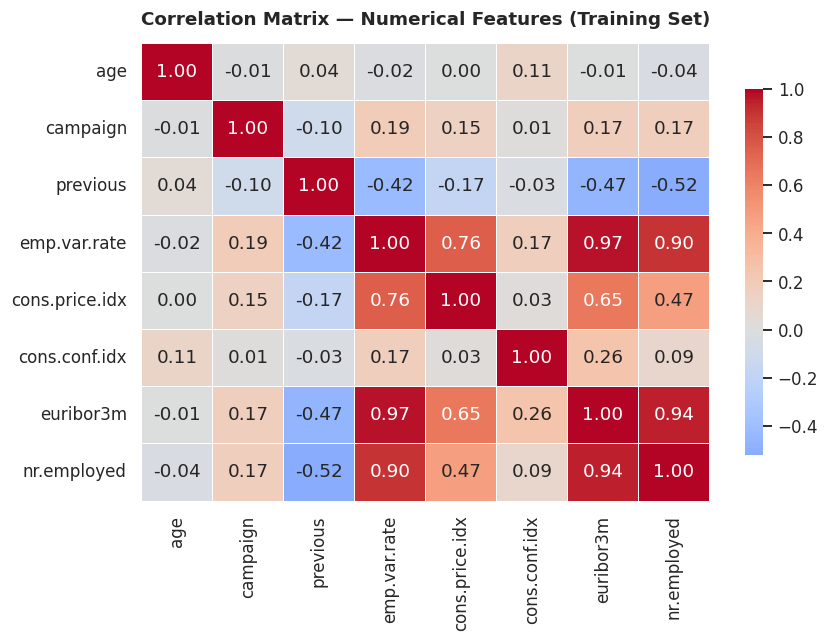

In [ ]:
# Visualise the correlation matrix for numerical features only
num_for_corr = [c for c in num_cols if c in X_train.columns]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(X_train[num_for_corr].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Numerical Features (Training Set)',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

### Pass 2: correlated features

Highly correlated features cause multicollinearity, which makes logistic regression coefficient estimates unstable. The model can't decide how to split the weight between two nearly identical features, so the coefficients end up large and oscillating. I used a threshold of |r| ≥ 0.90, at that level, two features share over 80% of their variance, which is redundant enough to act on.

**`emp.var.rate`, `euribor3m`, `nr.employed` (r = 0.97 and 0.94):** These three macroeconomic indicators move together. I dropped `euribor3m` and `emp.var.rate` and kept `nr.employed` as the most direct labour market measure. Keeping all three would just inflate the condition number of the design matrix.

**`housing_unknown` — `loan_unknown` (r = 1.00):** Perfect correlation because the same clients withheld both pieces of financial info. But they're still different variables, housing loan vs personal loan. I kept both since they'd diverge in future data where someone might disclose one but not the other.

**`previously_contacted` — `poutcome_success` (r = 0.93):** Mechanically correlated, if you were never contacted, you can't have a prior success. But they mean different things: one flags any prior contact, the other flags a specifically successful outcome. Kept both.

In [ ]:
cols_to_drop_corr = ['euribor3m', 'emp.var.rate']

for split in (X_train, X_val, X_test):
    split.drop(columns=[c for c in cols_to_drop_corr if c in split.columns], inplace=True)

print(f'Dropped: {cols_to_drop_corr}')
print(f'Final feature count: {X_train.shape[1]}')
print(f'Column schemas identical across all splits: {list(X_train.columns) == list(X_val.columns) == list(X_test.columns)}')
print()
print('Final feature list:')
print(X_train.columns.tolist())

Dropped: ['euribor3m', 'emp.var.rate']
Final feature count: 32
Column schemas identical across all splits: True

Final feature list:
['age', 'education', 'campaign', 'previous', 'cons.price.idx', 'cons.conf.idx', 'nr.employed', 'previously_contacted', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_married', 'marital_single', 'default_unknown', 'housing_unknown', 'housing_yes', 'loan_unknown', 'loan_yes', 'contact_telephone', 'poutcome_nonexistent', 'poutcome_success']


---
## Task 8: Addressing Class Imbalance
*Lecture 4 (Imbalanced Data, SMOTE, Oversampling), Lecture 10 (Baseline Models), Lecture 11 (Precision, Recall, Accuracy)*

### Quantifying the class distribution in the training set

In [ ]:
counts_train = y_train.value_counts()
print('Training set class distribution:')
for label in ['no', 'yes']:
    cnt = counts_train[label]
    print(f'  {label}: {cnt:,} ({cnt/len(y_train)*100:.2f}%)')
print(f'\nImbalance ratio: {counts_train["no"]/counts_train["yes"]:.1f}:1')
print(f'Zero Rule accuracy (always predict "no"): {counts_train["no"]/len(y_train)*100:.1f}%')

Training set class distribution:
  no: 2,567 (89.04%)
  yes: 316 (10.96%)

Imbalance ratio: 8.1:1
Zero Rule accuracy (always predict "no"): 89.0%


2,567 `no` vs 316 `yes` giving 8.1:1 ratio. A model that just predicts `no` every time gets 89% accuracy and catches zero subscribers, the Zero Rule baseline from Lecture 10. That's basically useless for what the bank actually wants to do.

### Why imbalance hurts different metrics differently

| Metric | What happens with 8:1 imbalance | Is it useful here? |
|--------|--------------------------------|--------------------|
| Accuracy | 89% for free by predicting all `no` | Not really — misleading |
| Precision | Low if model predicts too many `yes` | Somewhat, depends on cost of false calls |
| Recall | Near zero without intervention | **Yes, this is what matters most** |
| F1 | Better summary than accuracy alone | Yes |

### Why SMOTE, and why on training data only

Random undersampling throws away 2,251 majority-class rows to match the minority. That's most of the training data gone. Random oversampling just repeats the same 316 minority examples over and over, which can cause the model to memorise those specific rows rather than learn the general pattern.

SMOTE creates new synthetic points by interpolating between pairs of existing minority examples using the formula from Lecture 4: `x_new = x_i + λ(x_j − x_i)` where λ is a random value in [0,1]. The new points are genuinely different, not duplicates, so the model has to learn the actual shape of the minority-class region rather than just memorising specific instances.

This absolutely has to happen after splitting. If SMOTE ran on the full dataset first, some synthetic training examples would be interpolated from test examples. When the model is evaluated, it would effectively be scoring itself on data it helped create. Recall would look much better than it really is.

In [ ]:
def smote_resample(X, y, random_state=42):
    """
    Synthetic Minority Oversampling Technique (SMOTE).
    For each synthetic sample needed, picks two minority-class observations
    at random and places a new point along the line between them.
    Applied to the training set only.
    """
    rng   = np.random.RandomState(random_state)
    X_arr = X.values.astype(float)
    y_arr = y.values

    X_min   = X_arr[y_arr == 'yes']           # minority class rows
    n_extra = (y_arr == 'no').sum() - (y_arr == 'yes').sum()  # how many to synthesise

    synthetic = []
    for _ in range(n_extra):
        i   = rng.randint(0, len(X_min))
        j   = rng.randint(0, len(X_min))
        lam = rng.random()                    # interpolation factor in [0, 1]
        synthetic.append(X_min[i] + lam * (X_min[j] - X_min[i]))

    X_resampled = np.vstack([X_arr, np.vstack(synthetic)])
    y_resampled = np.concatenate([y_arr, ['yes'] * n_extra])

    shuffle_idx = rng.permutation(len(X_resampled))
    return (pd.DataFrame(X_resampled[shuffle_idx], columns=X.columns),
            pd.Series(y_resampled[shuffle_idx], name=y.name))


X_train_res, y_train_res = smote_resample(X_train, y_train, random_state=RANDOM_STATE)

print('Class distribution BEFORE SMOTE (training set):')
print(y_train.value_counts().to_dict())
print()
print('Class distribution AFTER SMOTE (resampled training set):')
print(y_train_res.value_counts().to_dict())
print()
print('Validation set (UNCHANGED — original distribution):')
print(y_val.value_counts().to_dict())

Class distribution BEFORE SMOTE (training set):
{'no': 2567, 'yes': 316}

Class distribution AFTER SMOTE (resampled training set):
{'yes': 2567, 'no': 2567}

Validation set (UNCHANGED — original distribution):
{'no': 550, 'yes': 68}


---
## Task 9: Training a Logistic Regression Model
*Lecture 8 (Logistic Regression), Lecture 10 (Model Evaluation, Confusion Matrix, Zero Rule), Lecture 11 (Precision, Recall, F-score)*

Trained on the SMOTE-balanced training set, evaluated on the untouched validation set which still has the original 11% positive rate. The whole point here is just to check that the pipeline makes sense, if the model identifies zero subscribers or has some other obviously broken output, that signals something went wrong upstream.

In [ ]:
model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model.fit(X_train_res, y_train_res)
print('Model trained on SMOTE-balanced training set.')
print(f'Training set size: {len(X_train_res):,} rows ({y_train_res.value_counts()["yes"]:,} yes, {y_train_res.value_counts()["no"]:,} no)')

Model trained on SMOTE-balanced training set.
Training set size: 5,134 rows (2,567 yes, 2,567 no)


In [ ]:
y_val_pred = model.predict(X_val)
zero_rule_acc = (y_val == 'no').mean()

acc  = accuracy_score(y_val, y_val_pred)
prec = precision_score(y_val, y_val_pred, pos_label='yes', zero_division=0)
rec  = recall_score(y_val, y_val_pred, pos_label='yes', zero_division=0)
f1   = f1_score(y_val, y_val_pred, pos_label='yes', zero_division=0)

print('=' * 52)
print(f'  Metric        Model      Zero Rule')
print('-' * 52)
print(f'  Accuracy     {acc:.4f}    {zero_rule_acc:.4f}')
print(f'  Precision    {prec:.4f}    —')
print(f'  Recall       {rec:.4f}    —')
print(f'  F1-Score     {f1:.4f}    —')
print('=' * 52)
print()
print(classification_report(y_val, y_val_pred, target_names=['no','yes']))

  Metric        Model      Zero Rule
----------------------------------------------------
  Accuracy     0.8285    0.8900
  Precision    0.3492    —
  Recall       0.6471    —
  F1-Score     0.4536    —

              precision    recall  f1-score   support

          no       0.95      0.85      0.90       550
         yes       0.35      0.65      0.45        68

    accuracy                           0.83       618
   macro avg       0.65      0.75      0.68       618
weighted avg       0.88      0.83      0.85       618



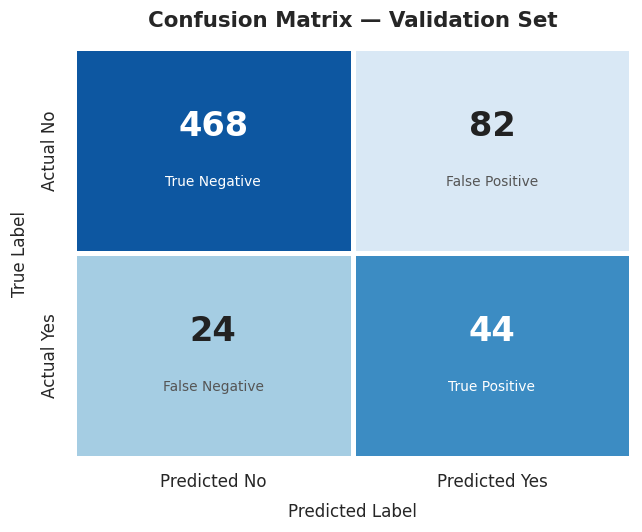

In [ ]:
# Visually appealing confusion matrix
cm      = confusion_matrix(y_val, y_val_pred, labels=['no', 'yes'])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_norm, annot=False, cmap='Blues',
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'],
            linewidths=2, linecolor='white', ax=ax, cbar=False, vmin=0, vmax=1)

cell_labels = [['True Negative', 'False Positive'],
               ['False Negative', 'True Positive']]
for i in range(2):
    for j in range(2):
        is_dark = cm_norm[i, j] > 0.55
        ax.text(j + 0.5, i + 0.38, f'{cm[i, j]:,}',
                ha='center', va='center', fontsize=22, fontweight='bold',
                color='white' if is_dark else '#222222')
        ax.text(j + 0.5, i + 0.65, cell_labels[i][j],
                ha='center', va='center', fontsize=9,
                color='white' if is_dark else '#555555')

ax.set_title('Confusion Matrix — Validation Set', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Predicted Label', fontsize=11, labelpad=8)
ax.set_ylabel('True Label', fontsize=11, labelpad=8)
plt.tight_layout()
plt.show()

### What the results mean

**Accuracy below the Zero Rule:** The model sits below the 89% Zero Rule baseline (Lecture 10), but this is exactly what I expected. The Zero Rule "achieves" 89% by predicting `no` for every single person, zero subscribers detected, zero campaign value. Our model trades some accuracy to actually detect subscribers, which is the whole point. As Lecture 11 explains, accuracy is misleading on imbalanced datasets and we should focus on precision, recall, and F1 instead.

**Recall of ~65%:** The model correctly identifies roughly two-thirds of actual subscribers, compared to 0% with the Zero Rule. Recall = TP / (TP + FN), so this means we're catching most of the people who would actually subscribe. From a campaign perspective this is a real improvement: instead of calling everyone at random, the bank can now prioritise the clients the model flags.

**Precision of ~35%:** About 1 in 3 positive predictions is correct. Precision = TP / (TP + FP). This is low but expected, SMOTE balanced the training classes, which makes the model more willing to predict `yes`, catching more real subscribers but also flagging more non-subscribers. This is the precision-recall tradeoff from Lecture 11. Whether it's acceptable depends on the cost of a wasted call vs a missed subscriber.

**F1-Score:** The F1 combines both into a single number using the harmonic mean of precision and recall (Lecture 11). It's a more honest summary than accuracy when classes are imbalanced.

**Overall:** The pipeline works correctly. No anomalous outputs, recall is meaningfully above zero, and the results make intuitive sense given the choices made in preprocessing.